**Instructions:**
- প্রতিটি cell এ `# YOUR CODE HERE` এর জায়গায় তোমার code লেখো।
- Expected output এর সাথে নিজের output মেলাও।
- `Shift + Enter` দিয়ে cell run করো।

---

## ⚙️ Setup — Run This First

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

np.random.seed(42)
data = {
    'Age':        [25, 32, np.nan, 45, 28, 60, 22, 38, np.nan, 55, 29, 200, 34, 41, 26],
    'Salary':     [30000, 55000, 48000, np.nan, 32000, 75000, 28000, 60000, 41000, 70000, 33000, 52000, np.nan, 63000, 29000],
    'City':       ['Dhaka','Chittagong','Dhaka','Sylhet',np.nan,'Dhaka','Rajshahi','Chittagong','Dhaka','Sylhet','Rajshahi','Dhaka','Chittagong',np.nan,'Dhaka'],
    'Education':  ['HSC','Graduate','Graduate','Masters','HSC','PhD','HSC','Graduate','Masters','PhD','HSC','Graduate','Graduate','Masters','HSC'],
    'Experience': [2, 8, 5, 15, 3, 30, 1, 12, 7, 25, 2, 9, 6, 18, 3],
    'Purchased':  [0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0]
}
df = pd.DataFrame(data)
print('Dataset loaded! Shape:', df.shape)
df.head()

Dataset loaded! Shape: (15, 6)


,Age,Salary,City,Education,Experience,Purchased
0,25.0,30000.0,Dhaka,HSC,2,0
1,32.0,55000.0,Chittagong,Graduate,8,1
2,NaN,48000.0,Dhaka,Graduate,5,1
3,45.0,NaN,Sylhet,Masters,15,1
4,28.0,32000.0,NaN,HSC,3,0


---
# 📌 Section 1: Exploratory Data Analysis
**Module 01 & 02**

### 🟢 EASY &nbsp;&nbsp; Question 1
Dataset এর **shape** বের করো — কতটি row এবং column আছে?

In [5]:
print(df.shape)

(15, 6)


**Expected Output:** `(15, 6)`

### 🟢 EASY &nbsp;&nbsp; Question 2
প্রতিটি column এর **data type** দেখাও।

In [6]:
# YOUR CODE HERE
# Hint: df.dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Age         13 non-null     float64
 1   Salary      13 non-null     float64
 2   City        13 non-null     object 
 3   Education   15 non-null     object 
 4   Experience  15 non-null     int64  
 5   Purchased   15 non-null     int64  
dtypes: float64(2), int64(2), object(2)
memory usage: 852.0+ bytes


### 🟢 EASY &nbsp;&nbsp; Question 3
Dataset এর **statistical summary** দেখাও — mean, std, min, max।

In [7]:
# YOUR CODE HERE
# Hint: df.describe()
df.describe()



,Age,Salary,Experience,Purchased
count,13.000000,13.000000,15.000000,15.000000
mean,48.846154,47384.615385,9.733333,0.600000
std,46.857668,16474.922668,8.778762,0.507093
min,22.000000,28000.000000,1.000000,0.000000
25%,28.000000,32000.000000,3.000000,0.000000
50%,34.000000,48000.000000,7.000000,1.000000
75%,45.000000,60000.000000,13.500000,1.000000
max,200.000000,75000.000000,30.000000,1.000000


### 🟢 EASY &nbsp;&nbsp; Question 4
**City** column এ কতটি unique value আছে এবং প্রতিটি কতবার আসে?

In [8]:
# YOUR CODE HERE
# Hint: .nunique() এবং .value_counts()

print(df['City'].nunique())
print(df['City'].unique())
df['City'].value_counts()


4
['Dhaka' 'Chittagong' 'Sylhet' nan 'Rajshahi']


,count
City,
Dhaka,6
Chittagong,3
Sylhet,2
Rajshahi,2


### 🟡 MEDIUM &nbsp;&nbsp; Question 5
**Age** column এর mean, median এবং mode আলাদাভাবে বের করো এবং তিনটি একসাথে print করো।

In [9]:
# YOUR CODE HERE
# Hint: .mean(), .median(), .mode()[0]

print(df['Age'].mean())
print(df['Age'].median())
print(df['Age'].mode()) #


48.84615384615385
34.0
0      22.0
1      25.0
2      26.0
3      28.0
4      29.0
5      32.0
6      34.0
7      38.0
8      41.0
9      45.0
10     55.0
11     60.0
12    200.0
Name: Age, dtype: float64


### 🟡 MEDIUM &nbsp;&nbsp; Question 6
**Age** এর distribution দেখানোর জন্য histogram plot করো। Title এবং axis labels দাও।

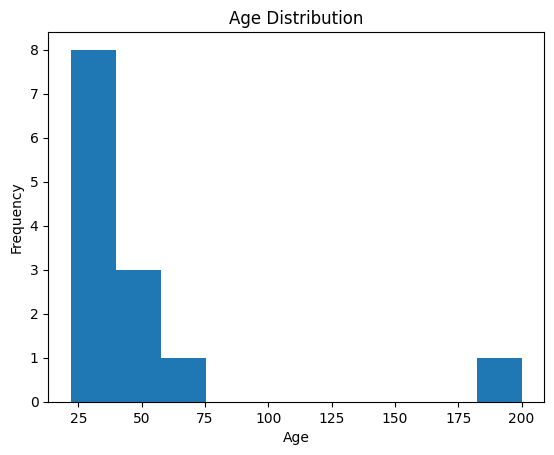

In [10]:
# YOUR CODE HERE
# Hint: plt.hist() বা df['Age'].plot(kind='hist')
# plt.title(), plt.xlabel(), plt.ylabel() দিতে ভুলো না

plt.hist(df['Age'])
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### 🟡 MEDIUM &nbsp;&nbsp; Question 7
**Salary vs Experience** scatter plot করো এবং দেখো কোনো pattern আছে কিনা।

<Axes: xlabel='Experience', ylabel='Salary'>

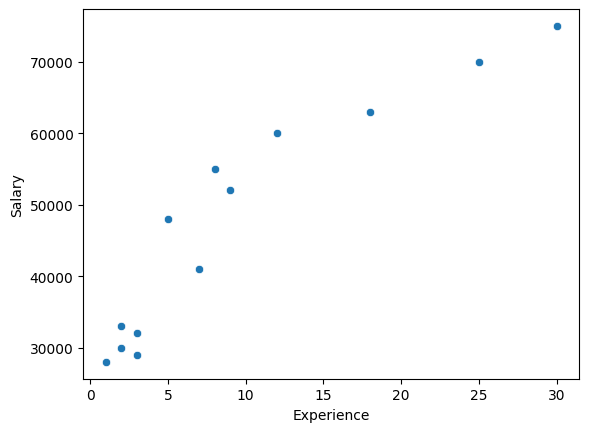

In [11]:
# YOUR CODE HERE
# Hint: sns.scatterplot(data=df, x='Experience', y='Salary')
sns.scatterplot(data=df,x='Experience', y='Salary')


### 🔴 HARD &nbsp;&nbsp; Question 8
Numerical columns এর correlation বের করো এবং **heatmap** দিয়ে visualize করো। `annot=True` দাও।

> চিন্তা করো: Age এবং Experience এর মধ্যে কি strong correlation আছে? কেন?

<Axes: >

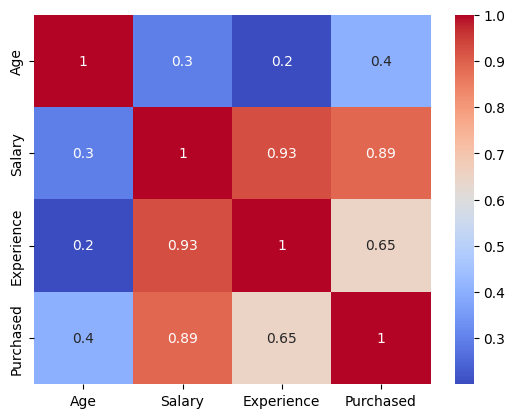

In [12]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')

---
# 📌 Section 2: Train-Test Split & Missing Value Handling
**Module 03**

### 🟢 EASY &nbsp;&nbsp; Question 9
প্রতিটি column এ **কতটি missing value** আছে তা বের করো।

In [13]:
# YOUR CODE HERE
# Hint: .isnull().sum()

df.isnull().sum()


,0
Age,2
Salary,2
City,2
Education,0
Experience,0
Purchased,0


**Expected:** Age=2, Salary=2, City=2

### 🟢 EASY &nbsp;&nbsp; Question 10
**Age** এর missing values **mean** দিয়ে এবং **City** এর missing values **mode** দিয়ে fill করো।

In [14]:
df_clean = df.copy()

# YOUR CODE HERE
# Age → mean

# City → mode
from sklearn.impute import SimpleImputer
age_imputer=SimpleImputer(strategy='mean')
age_imputer.fit(df_clean[['Age']])
df_clean['Age']=age_imputer.transform(df_clean[['Age']]).ravel()


city_imputer=SimpleImputer(strategy='most_frequent')
city_imputer.fit(df_clean[['City']])
df_clean['City']=city_imputer.transform(df_clean[['City']]).ravel()

print(df_clean['Age'])
print(df_clean['City'])


0      25.000000
1      32.000000
2      48.846154
3      45.000000
4      28.000000
5      60.000000
6      22.000000
7      38.000000
8      48.846154
9      55.000000
10     29.000000
11    200.000000
12     34.000000
13     41.000000
14     26.000000
Name: Age, dtype: float64
0          Dhaka
1     Chittagong
2          Dhaka
3         Sylhet
4          Dhaka
5          Dhaka
6       Rajshahi
7     Chittagong
8          Dhaka
9         Sylhet
10      Rajshahi
11         Dhaka
12    Chittagong
13         Dhaka
14         Dhaka
Name: City, dtype: object


### 🟡 MEDIUM &nbsp;&nbsp; Question 11
**Salary** এর missing values **median** দিয়ে fill করো। Fill করার আগে ও পরে missing count দেখাও।

In [15]:
# YOUR CODE HERE
# Before count print করো

# Fill করো

# After count print করো

salary_imputer=SimpleImputer(strategy='median')
salary_imputer.fit(df_clean[['Salary']])
df_clean['Salary']=salary_imputer.transform(df_clean[['Salary']]).ravel()
print(df_clean['Salary'])

print('\n missing values is : ', df_clean['Salary'].isnull().sum())


0     30000.0
1     55000.0
2     48000.0
3     48000.0
4     32000.0
5     75000.0
6     28000.0
7     60000.0
8     41000.0
9     70000.0
10    33000.0
11    52000.0
12    48000.0
13    63000.0
14    29000.0
Name: Salary, dtype: float64

 missing values is :  0


### 🟡 MEDIUM &nbsp;&nbsp; Question 12
**Train-Test Split** করো — 80% training, 20% testing। `random_state=42`।

> Feature (X): Age, Salary, Experience | Target (y): Purchased

In [16]:
X = df_clean[['Age', 'Salary', 'Experience']]
y = df_clean['Purchased']

# YOUR CODE HERE
# X_train, X_test, y_train, y_test = train_test_split(...)

# Print sizes
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(12, 3)
(3, 3)
(12,)
(3,)


**Expected:** Train size: 12, Test size: 3

### 🔴 HARD &nbsp;&nbsp; Question 13
Train-Test Split করার পরে `y_train` এবং `y_test` এ **class distribution** (0 এবং 1 এর ratio) দেখাও। Distribution কি balanced?

> Hint: `.value_counts(normalize=True)` দিয়ে percentage বের করো।

In [17]:
# YOUR CODE HERE
# y_train distribution

# y_test distribution

# তোমার observation লেখো (comment এ):
# "Train এ class 0 আছে X%, class 1 আছে Y%..."

# y_train distribution
print("y_train distribution:")
print(y_train.value_counts(normalize=True))

print("\n")

# y_test distribution
print("y_test distribution:")
print(y_test.value_counts(normalize=True))

y_train distribution:
Purchased
1    0.583333
0    0.416667
Name: proportion, dtype: float64


y_test distribution:
Purchased
1    0.666667
0    0.333333
Name: proportion, dtype: float64


---
# 📌 Section 3: Outlier Detection and Handling
**Module 05 & 06**

### 🟢 EASY &nbsp;&nbsp; Question 14
**Age** column এর **boxplot** তৈরি করো।

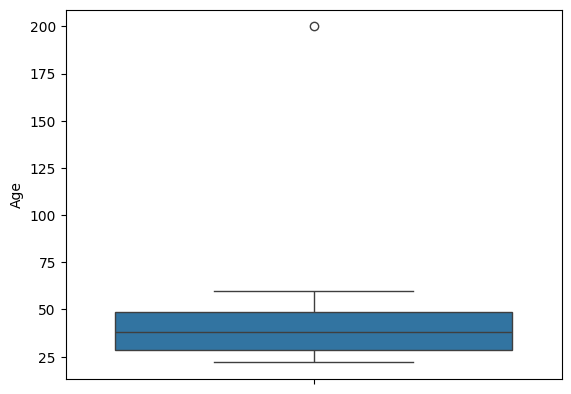

In [18]:
# YOUR CODE HERE
# Hint: sns.boxplot(y=df_clean['Age'])

sns.boxplot(y=df_clean['Age'])
plt.show()


**Note:** Age=200 clearly একটি outlier।

### 🟡 MEDIUM &nbsp;&nbsp; Question 15
**IQR Method** দিয়ে **Age** column এর outlier detect করো এবং outlier rows দেখাও।

> IQR = Q3 - Q1 | Lower = Q1 - 1.5×IQR | Upper = Q3 + 1.5×IQR

In [19]:
Q1 = df_clean['Age'].quantile(0.25)
Q3 = df_clean['Age'].quantile(0.75)

# YOUR CODE HERE
# IQR calculate করো

# Lower এবং Upper bound

# Outlier rows দেখাও
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=df_clean[(df_clean['Age']<lower_bound) | (df_clean['Age']>upper_bound)]

print(outliers)

df_clean.shape

      Age   Salary   City Education  Experience  Purchased
11  200.0  52000.0  Dhaka  Graduate           9          1


(15, 6)

**Expected:** Age=200 row outlier হিসেবে detected হবে।

### 🟡 MEDIUM &nbsp;&nbsp; Question 16
**Z-Score Method** দিয়ে outlier detect করো। |Z| > 3 হলে outlier।

> Z = (x - mean) / std

In [20]:
# YOUR CODE HERE
mean_age = df_clean['Age'].mean()
std_age  = df_clean['Age'].std()

# Z-score calculate করো

# |Z| > 3 এমন rows দেখাও

z_score=(df_clean['Age']-mean_age)/std_age  # df_clean e noton column  kora jai bt korlam  na
outliers=df_clean[abs(z_score)>3]
print(outliers)
print(len(outliers))

      Age   Salary   City Education  Experience  Purchased
11  200.0  52000.0  Dhaka  Graduate           9          1
1


### 🟡 MEDIUM &nbsp;&nbsp; Question 17
IQR method এ detected outlier rows **remove** করো। নতুন shape দেখাও।

In [21]:
# YOUR CODE HERE
# Hint: bound এর মধ্যে আছে এমন rows রাখো
df_clean.drop(outliers.index,inplace=True)

df_clean.shape

(14, 6)

**Expected:** Shape (14, 6) — 1 row removed.

### 🔴 HARD &nbsp;&nbsp; Question 18
Outlier remove করার বদলে **cap** করো (Winsorization)। তারপর before vs after boxplot side-by-side দেখাও।

> Cap মানে: outlier value কে bound এর value দিয়ে replace করা।

22.0
60.0
23.17
58.05
0     25.000000
1     32.000000
2     48.846154
3     45.000000
4     28.000000
5     58.050000
6     23.170000
7     38.000000
8     48.846154
9     55.000000
10    29.000000
12    34.000000
13    41.000000
14    26.000000
Name: Age, dtype: float64


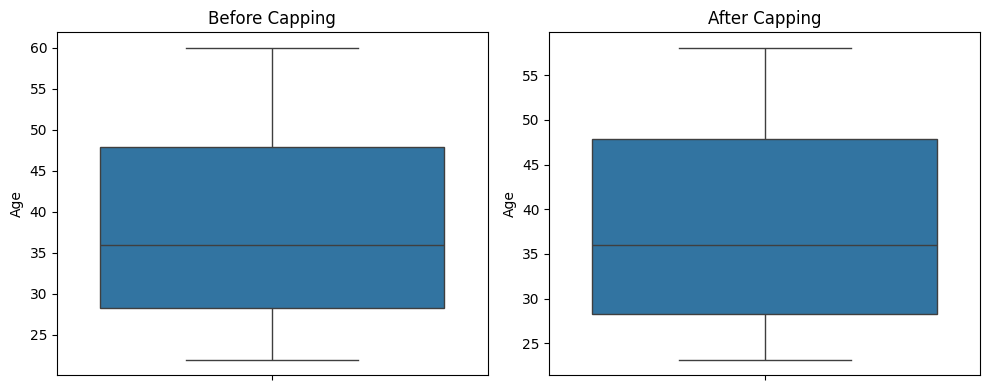

23.17
58.05


In [36]:
df_capped = df_clean.copy()

# YOUR CODE HERE
print(df_capped['Age'].min())
print(df_capped['Age'].max())
x=3
x=x/100
min_range=df_clean['Age'].quantile(x)
max_range=df_clean['Age'].quantile(1-x)
print(min_range)
print(max_range)

# Step 1: Cap করো
# Hint: df_capped['Age'] = df_capped['Age'].clip(lower=lower_bound, upper=upper_bound)

df_capped['Age']=df_capped['Age'].clip(min_range,max_range) # capped nam e akta copy create korse opoire dekho
print(df_capped['Age'])




fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# axes[0] → Before (df_clean)

sns.boxplot(y=df_clean['Age'], ax=axes[0])
axes[0].set_title("Before Capping")
# axes[1] → After (df_capped)

sns.boxplot(y=df_capped['Age'], ax=axes[1])
axes[1].set_title("After Capping")
plt.tight_layout()
plt.show()

print(df_capped['Age'].min())
print(df_capped['Age'].max())

---
# 📌 Section 4: Encoding
**Module 07**

### 🟢 EASY &nbsp;&nbsp; Question 19
**Label Encoding** দিয়ে **Education** column কে numerical করো।

In [23]:
df_encoded = df_clean.copy()
le = LabelEncoder()

# YOUR CODE HERE
# df_encoded['Education_Encoded'] = le.fit_transform(...)


df_encoded['Education_Encoded'] = le.fit_transform(df_encoded['Education'])
df_encoded

# LabelEncoder নিজে unique value বের করবে এবং alphabetical order অনুযায়ী সংখ্যা দেবে
# random না, alphabetical sorting করে encoding দেয়।


,Age,Salary,City,Education,Experience,Purchased,Education_Encoded
0,25.000000,30000.0,Dhaka,HSC,2,0,1
1,32.000000,55000.0,Chittagong,Graduate,8,1,0
2,48.846154,48000.0,Dhaka,Graduate,5,1,0
3,45.000000,48000.0,Sylhet,Masters,15,1,2
4,28.000000,32000.0,Dhaka,HSC,3,0,1
5,60.000000,75000.0,Dhaka,PhD,30,1,3
6,22.000000,28000.0,Rajshahi,HSC,1,0,1
7,38.000000,60000.0,Chittagong,Graduate,12,1,0
8,48.846154,41000.0,Dhaka,Masters,7,0,2
9,55.000000,70000.0,Sylhet,PhD,25,1,3


### 🟢 EASY &nbsp;&nbsp; Question 20
**One-Hot Encoding** দিয়ে **City** column কে encode করো। `pd.get_dummies()` ব্যবহার করো।

In [24]:
# YOUR CODE HERE
# Hint: pd.get_dummies(df_encoded, columns=['City'], drop_first=True)

from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# One-Hot Encoding City column
df_encoded = pd.get_dummies(df_clean, columns=['City'], drop_first=True)


df_encoded



,Age,Salary,Education,Experience,Purchased,City_Dhaka,City_Rajshahi,City_Sylhet
0,25.000000,30000.0,HSC,2,0,True,False,False
1,32.000000,55000.0,Graduate,8,1,False,False,False
2,48.846154,48000.0,Graduate,5,1,True,False,False
3,45.000000,48000.0,Masters,15,1,False,False,True
4,28.000000,32000.0,HSC,3,0,True,False,False
5,60.000000,75000.0,PhD,30,1,True,False,False
6,22.000000,28000.0,HSC,1,0,False,True,False
7,38.000000,60000.0,Graduate,12,1,False,False,False
8,48.846154,41000.0,Masters,7,0,True,False,False
9,55.000000,70000.0,PhD,25,1,False,False,True


**Note:** `drop_first=True` দিলে dummy variable trap avoid হয়।

### 🟡 MEDIUM &nbsp;&nbsp; Question 21
Label Encoded **Education** এর mapping dictionary দেখাও — কোন label কোন number পেয়েছে।

In [25]:
# YOUR CODE HERE
# Hint: dict(zip(le.classes_, le.transform(le.classes_)))
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_clean['Education_Encoded'] = le.fit_transform(df_clean['Education']) # ami clean copy ta use korsi

# mapping dictionary
mapping = dict(zip(le.classes_, le.transform(le.classes_)))

display(mapping)
df_clean



{'Graduate': np.int64(0),
 'HSC': np.int64(1),
 'Masters': np.int64(2),
 'PhD': np.int64(3)}

,Age,Salary,City,Education,Experience,Purchased,Education_Encoded
0,25.000000,30000.0,Dhaka,HSC,2,0,1
1,32.000000,55000.0,Chittagong,Graduate,8,1,0
2,48.846154,48000.0,Dhaka,Graduate,5,1,0
3,45.000000,48000.0,Sylhet,Masters,15,1,2
4,28.000000,32000.0,Dhaka,HSC,3,0,1
5,60.000000,75000.0,Dhaka,PhD,30,1,3
6,22.000000,28000.0,Rajshahi,HSC,1,0,1
7,38.000000,60000.0,Chittagong,Graduate,12,1,0
8,48.846154,41000.0,Dhaka,Masters,7,0,2
9,55.000000,70000.0,Sylhet,PhD,25,1,3


**Expected:** `{'Graduate': 0, 'HSC': 1, 'Masters': 2, 'PhD': 3}`

### 🔴 HARD &nbsp;&nbsp; Question 22
Label Encoding এবং One-Hot Encoding এর মধ্যে পার্থক্য কী? **Education** column এ কোনটা ব্যবহার করা সঠিক এবং কেন?

> দুটো method ই apply করো এবং output compare করো। তারপর নিচে comment এ তোমার reasoning লেখো।

In [26]:
# Method 1: Label Encoding
df_label=df.copy() # ai copy ta ami nijei banaisi
le=LabelEncoder()
df_label['Education_Encoded']=le.fit_transform(df_label['Education'])
print(df_label[['Education','Education_Encoded']])

# Method 2: One-Hot Encoding

df_onehot = df.copy()

education_ohe = OneHotEncoder(sparse_output=False)

# fit + transform aksathe
encoded_df = education_ohe.fit_transform(df_onehot[['Education']])

# encoded array → DataFrame
encoded_df = pd.DataFrame(encoded_df,columns=education_ohe.get_feature_names_out(['Education'])) # ata akto new line tbe effective babe run hocce ata cara run hoitesena

# concat (axis=1 = column-wise)
df_onehot = pd.concat([df_onehot, encoded_df], axis=1)

df_onehot.head(14)



# তোমার answer (comment এ লেখো):
#  Education column এর জন্য One-Hot Encoding best

# Education column এ _One-Hot Encoding best__ ভালো কারণ ___________:

# Education column এর জন্য One-Hot Encoding best, কারণ এটি কোনো fake order তৈরি করে না এবং

# প্রতিটি category কে আলাদা binary column হিসেবে represent করে, ফলে model সঠিকভাবে শিখতে পারে।





   Education  Education_Encoded
0        HSC                  1
1   Graduate                  0
2   Graduate                  0
3    Masters                  2
4        HSC                  1
5        PhD                  3
6        HSC                  1
7   Graduate                  0
8    Masters                  2
9        PhD                  3
10       HSC                  1
11  Graduate                  0
12  Graduate                  0
13   Masters                  2
14       HSC                  1


,Age,Salary,City,Education,Experience,Purchased,Education_Graduate,Education_HSC,Education_Masters,Education_PhD
0,25.0,30000.0,Dhaka,HSC,2,0,0.0,1.0,0.0,0.0
1,32.0,55000.0,Chittagong,Graduate,8,1,1.0,0.0,0.0,0.0
2,NaN,48000.0,Dhaka,Graduate,5,1,1.0,0.0,0.0,0.0
3,45.0,NaN,Sylhet,Masters,15,1,0.0,0.0,1.0,0.0
4,28.0,32000.0,NaN,HSC,3,0,0.0,1.0,0.0,0.0
5,60.0,75000.0,Dhaka,PhD,30,1,0.0,0.0,0.0,1.0
6,22.0,28000.0,Rajshahi,HSC,1,0,0.0,1.0,0.0,0.0
7,38.0,60000.0,Chittagong,Graduate,12,1,1.0,0.0,0.0,0.0
8,NaN,41000.0,Dhaka,Masters,7,0,0.0,0.0,1.0,0.0
9,55.0,70000.0,Sylhet,PhD,25,1,0.0,0.0,0.0,1.0


---
# 📌 Section 5: Scaling
**Module 08**

### 🟢 EASY &nbsp;&nbsp; Question 23
**MinMaxScaler** দিয়ে **Experience** column কে 0–1 এর মধ্যে scale করো।

> Formula: x_scaled = (x - min) / (max - min)

In [27]:
mm_scaler = MinMaxScaler()

df_scaled  = df_clean.copy() # ora age tekei akyta copy banai rakse

# YOUR CODE HERE
from sklearn.preprocessing import MinMaxScaler

mms=MinMaxScaler() # atar moddwe sotro coel ashse o-1 er modde range soby cole ashe

df_scaled['Experience']=mms.fit_transform(df_scaled[['Experience']])
df_scaled



,Age,Salary,City,Education,Experience,Purchased,Education_Encoded
0,25.000000,30000.0,Dhaka,HSC,0.034483,0,1
1,32.000000,55000.0,Chittagong,Graduate,0.241379,1,0
2,48.846154,48000.0,Dhaka,Graduate,0.137931,1,0
3,45.000000,48000.0,Sylhet,Masters,0.482759,1,2
4,28.000000,32000.0,Dhaka,HSC,0.068966,0,1
5,60.000000,75000.0,Dhaka,PhD,1.000000,1,3
6,22.000000,28000.0,Rajshahi,HSC,0.000000,0,1
7,38.000000,60000.0,Chittagong,Graduate,0.379310,1,0
8,48.846154,41000.0,Dhaka,Masters,0.206897,0,2
9,55.000000,70000.0,Sylhet,PhD,0.827586,1,3


**Expected:** Experience values এখন 0.0 থেকে 1.0 এর মধ্যে।

### 🟡 MEDIUM &nbsp;&nbsp; Question 24
**StandardScaler** দিয়ে **Age** এবং **Salary** scale করো। Scaling এর পর mean ≈ 0 এবং std ≈ 1 verify করো।

In [32]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()

# YOUR CODE HERE
std_scaler=StandardScaler()



# Scale করো
df_scaled['Age']=std_scaler.fit_transform(df_scaled[['Age']])
df_scaled['Salary']=std_scaler.fit_transform(df_scaled[['Salary']])

# Verify: mean এবং std print করো
# Verify mean and std

print("Mean:")
print(df_scaled[['Age', 'Salary']].mean())

print("\nStd:")
print(df_scaled[['Age', 'Salary']].std())

# সহজ ট্রিক: StandardScaler প্রথমে mean বাদ দেয়, তারপর std দিয়ে ভাগ দেয়। Mean বাদ দেওয়ার কারণেই data-এর center 0-তে চলে আসে

Mean:
Age       6.344132e-17
Salary    3.172066e-17
dtype: float64

Std:
Age       1.037749
Salary    1.037749
dtype: float64


**Expected:** Mean ≈ 0.0, Std ≈ 1.0

### 🟡 MEDIUM &nbsp;&nbsp; Question 25
**Age** column এর scaling এর আগে ও পরে distribution **side-by-side histogram** দিয়ে compare করো।

23.17
58.05
0     25.000000
1     32.000000
2     48.846154
3     45.000000
4     28.000000
5     58.050000
6     23.170000
7     38.000000
8     48.846154
9     55.000000
10    29.000000
12    34.000000
13    41.000000
14    26.000000
Name: Age, dtype: float64


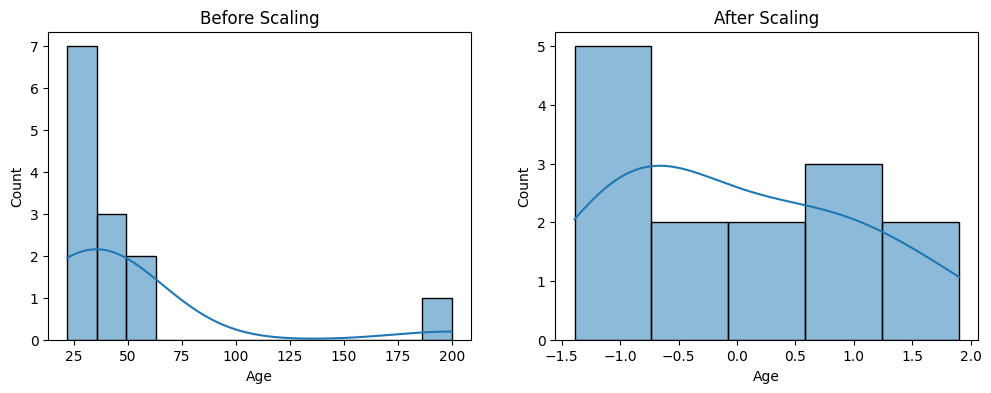

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# YOUR CODE HERE
x=3
x=x/100
min_range=df_clean['Age'].quantile(x)
max_range=df_clean['Age'].quantile(1-x)
print(min_range)
print(max_range)
df_capped['Age']=df_capped['Age'].clip(min_range,max_range) # capped nam e akta copy create korse opoire dekho
print(df_capped['Age'])

# axes[0] → Before scaling

sns.histplot(df['Age'], kde=True, ax=axes[0])
axes[0].set_title("Before Scaling")

# axes[1] → After scaling
sns.histplot(df_scaled['Age'], kde=True, ax=axes[1])
axes[1].set_title("After Scaling")


plt.show()

### 🔴 HARD &nbsp;&nbsp; Question 26
StandardScaler এবং MinMaxScaler এর মধ্যে পার্থক্য কী? **Salary** column এ দুটোই apply করো এবং output compare করো।

> কোন situation এ কোনটা use করবে? Comment এ reasoning লেখো।

In [45]:
salary = df_clean[['Salary']]
salary
# StandardScaler apply করো
df_standardscaled=StandardScaler()
df_standardscaled.fit(df_clean[['Salary']])
df_clean['Salary']=df_standardscaled.transform(df_clean[['Salary']])
display(df_clean)

# MinMaxScaler apply করো
df_minmaxscaled=MinMaxScaler()
df_minmaxscaled.fit(df_clean[['Salary']])
df_clean['Salary']=df_minmaxscaled.transform(df_clean[['Salary']])
display(df_clean)

# StandardScaler data কে mean ≈ 0 এবং standard deviation ≈ 1 এ transform করে, তাই negative ও positive value থাকতে পারে।
# MinMaxScaler data কে 0 থেকে 1 range এর মধ্যে নিয়ে আসে।
# StandardScaler distribution based scaling করে, whereas MinMaxScaler range based scaling করে।


# দুটো result compare করো (print অথবা plot)





,Age,Salary,City,Education,Experience,Purchased,Education_Encoded
0,25.000000,-1.127618,Dhaka,HSC,2,0,1
1,32.000000,0.516825,Chittagong,Graduate,8,1,0
2,48.846154,0.056381,Dhaka,Graduate,5,1,0
3,45.000000,0.056381,Sylhet,Masters,15,1,2
4,28.000000,-0.996063,Dhaka,HSC,3,0,1
5,60.000000,1.832380,Dhaka,PhD,30,1,3
6,22.000000,-1.259174,Rajshahi,HSC,1,0,1
7,38.000000,0.845714,Chittagong,Graduate,12,1,0
8,48.846154,-0.404063,Dhaka,Masters,7,0,2
9,55.000000,1.503491,Sylhet,PhD,25,1,3


,Age,Salary,City,Education,Experience,Purchased,Education_Encoded
0,25.000000,0.042553,Dhaka,HSC,2,0,1
1,32.000000,0.574468,Chittagong,Graduate,8,1,0
2,48.846154,0.425532,Dhaka,Graduate,5,1,0
3,45.000000,0.425532,Sylhet,Masters,15,1,2
4,28.000000,0.085106,Dhaka,HSC,3,0,1
5,60.000000,1.000000,Dhaka,PhD,30,1,3
6,22.000000,0.000000,Rajshahi,HSC,1,0,1
7,38.000000,0.680851,Chittagong,Graduate,12,1,0
8,48.846154,0.276596,Dhaka,Masters,7,0,2
9,55.000000,0.893617,Sylhet,PhD,25,1,3


 আসল concept 😄


> "Formula তো `(value - mean) / std`। যদি mean = 0 আর std = 1 হয়ে যায়, তাহলে কী হচ্ছে?"

এখানে একটা ভুল বোঝাবুঝি আছে।

Formula:

(value - mean) / std

এখানে **mean = 0 এবং std = 1 হলো scaling-এর পরের data-এর property**, formula-এ বসানোর mean/std না।

---

ধরো original Salary:


30000, 50000, 70000

Original mean:

50000

Original std:

16329 (ধরি)
```

এখন StandardScaler করবে:

text

30000 → (30000 - 50000) / 16329 = -1.22

50000 → (50000 - 50000) / 16329 = 0

70000 → (70000 - 50000) / 16329 = 1.22


নতুন data:

-1.22, 0, 1.22


---

এখন এই **নতুন data-এর mean** বের করলে:

```text
(-1.22 + 0 + 1.22) / 3 = 0
```

অর্থাৎ mean ≈ 0

আর std বের করলে ≈ 1 হবে।

---

তাই:

❌ Formula-এ mean=0, std=1 বসানো হয় না।

✅ Original data-এর mean ও std ব্যবহার করে transform করা হয়।

✅ Transform হওয়ার পরে নতুন data-এর mean≈0 এবং std≈1 হয়ে যায়।

---

সহজ ট্রিক:

```text
Original Data
      ↓
(value - old_mean) / old_std
      ↓
Scaled Data
(mean ≈ 0, std ≈ 1)
```

অর্থাৎ **mean=0, std=1 হলো result**, input না। 🎯


কখন কোনটা use করবে?

StandardScaler use করো যখন:

Data প্রায় normal distribution

Linear models (Logistic Regression, SVM)

PCA / ML algorithms sensitive to mean/std

 Example:

Salary prediction, regression problems

MinMaxScaler use করো যখন:

Neural Network / Deep Learning

Data bounded দরকার (0–1)

Image, activation functions (sigmoid/relu)

Example:

Image pixels, ANN, CNN

📝 Final Reasoning (Exam answer)

StandardScaler data কে mean 0 এবং standard deviation 1 এ transform করে, যা normally distributed data এবং linear models এর জন্য উপযুক্ত। MinMaxScaler data কে 0 থেকে 1 range এর মধ্যে নিয়ে আসে, যা neural networks এবং bounded input এর জন্য ভালো। তাই distribution based model এ StandardScaler এবং range based model এ MinMaxScaler ব্যবহার করা হয়।

Easy memory trick:

StandardScaler = "shape fix" (center করে)

MinMaxScaler = "range fix" (0–1 এ আনে)

---
# 🌟 Bonus: Full Pipeline
**Combine everything — end-to-end preprocessing**

### 🔴 HARD &nbsp;&nbsp; Question 27 (Bonus)
নিচের সব steps follow করে একটি **complete preprocessing pipeline** তৈরি করো:

1. Missing values handle করো
2. Outliers cap করো (IQR method)
3. City → One-Hot Encode
4. Education → Label Encode
5. Age, Salary, Experience → StandardScale
6. 80/20 Train-Test Split
7. Final train/test shape print করো

In [56]:
df_pipeline = df.copy()

# Step 1: Missing values
df_pipeline.isnull().sum()
from sklearn.impute import SimpleImputer

age_imputer=SimpleImputer(strategy='mean')
age_imputer.fit(df_pipeline[['Age']])
df_pipeline['Age']=age_imputer.transform(df_pipeline[['Age']]).ravel()

salary_imputer=SimpleImputer(strategy='median')
salary_imputer.fit(df_pipeline[['Salary']])
df_pipeline['Salary']=salary_imputer.transform(df_pipeline[['Salary']]).ravel()

city_imputer=SimpleImputer(strategy='most_frequent')
city_imputer.fit(df_pipeline[['City']])
df_pipeline['City']=city_imputer.transform(df_pipeline[['City']]).ravel()


# Step 2: Outlier capping

Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers=df[(df['Age'] < lower) | (df['Age'] > upper)]

display(outliers)

# Step 3: One-Hot Encoding
from sklearn.preprocessing import OneHotEncoder
city_ohe=OneHotEncoder(sparse_output=False)
city_ohe.fit(df_pipeline[['City']])
encoded_df=city_ohe.transform(df_pipeline[['City']])
encoded_df=pd.DataFrame(encoded_df,columns=city_ohe.get_feature_names_out(['City']))

df_pipeline=pd.concat([df_pipeline,encoded_df],axis=1)

# Step 4: Label Encoding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df_pipeline['Education_Encoded']=le.fit_transform(df_pipeline['Education'])


# Step 5: Standard Scaling
ss=StandardScaler()
df_pipeline[['Age','Salary','Experience']]=ss.fit_transform(df_pipeline[['Age','Salary','Experience']])


# Step 6: Train-Test Split

x=df_pipeline.drop(['City','Education','Salary'],axis=1)
y=df_pipeline['Salary']

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)



# Step 7: Print shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


,Age,Salary,City,Education,Experience,Purchased
11,200.0,52000.0,Dhaka,Graduate,9,1


X_train: (12, 3)
X_test: (3, 3)
y_train: (12,)
y_test: (3,)


In [57]:
df_pipeline

,Age,Salary,City,Education,Experience,Purchased,City_Chittagong,City_Dhaka,City_Rajshahi,City_Sylhet,Education_Encoded
0,-5.689743e-01,-1.185217,Dhaka,HSC,-0.911832,0,0.0,1.0,0.0,0.0,1
1,-4.019528e-01,0.511181,Chittagong,Graduate,-0.204376,1,1.0,0.0,0.0,0.0,0
2,1.695370e-16,0.036190,Dhaka,Graduate,-0.558104,1,0.0,1.0,0.0,0.0,0
3,-9.177005e-02,0.036190,Sylhet,Masters,0.620989,1,0.0,0.0,0.0,1.0,2
4,-4.973937e-01,-1.049505,Dhaka,HSC,-0.793923,0,0.0,1.0,0.0,0.0,1
5,2.661332e-01,1.868300,Dhaka,PhD,2.389630,1,0.0,1.0,0.0,0.0,3
6,-6.405550e-01,-1.320929,Rajshahi,HSC,-1.029742,0,0.0,0.0,1.0,0.0,1
7,-2.587916e-01,0.850461,Chittagong,Graduate,0.267261,1,1.0,0.0,0.0,0.0,0
8,1.695370e-16,-0.438802,Dhaka,Masters,-0.322286,0,0.0,1.0,0.0,0.0,2
9,1.468321e-01,1.529020,Sylhet,PhD,1.800083,1,0.0,0.0,0.0,1.0,3


In [58]:
x_train

,Age,Experience,Purchased,City_Chittagong,City_Dhaka,City_Rajshahi,City_Sylhet,Education_Encoded
13,-1.872109e-01,0.974717,1,0.0,1.0,0.0,0.0,2
5,2.661332e-01,2.389630,1,0.0,1.0,0.0,0.0,3
8,1.695370e-16,-0.322286,0,0.0,1.0,0.0,0.0,2
2,1.695370e-16,-0.558104,1,0.0,1.0,0.0,0.0,0
1,-4.019528e-01,-0.204376,1,1.0,0.0,0.0,0.0,0
14,-5.451141e-01,-0.793923,0,0.0,1.0,0.0,0.0,1
4,-4.973937e-01,-0.793923,0,0.0,1.0,0.0,0.0,1
7,-2.587916e-01,0.267261,1,1.0,0.0,0.0,0.0,0
10,-4.735335e-01,-0.911832,0,0.0,0.0,1.0,0.0,1
12,-3.542324e-01,-0.440195,1,1.0,0.0,0.0,0.0,0


In [59]:
x_test

,Age,Experience,Purchased,City_Chittagong,City_Dhaka,City_Rajshahi,City_Sylhet,Education_Encoded
9,0.146832,1.800083,1,0.0,0.0,0.0,1.0,3
11,3.606563,-0.086467,1,0.0,1.0,0.0,0.0,0
0,-0.568974,-0.911832,0,0.0,1.0,0.0,0.0,1


nije check out korlam kono outlier ace nki

<Axes: ylabel='Age'>

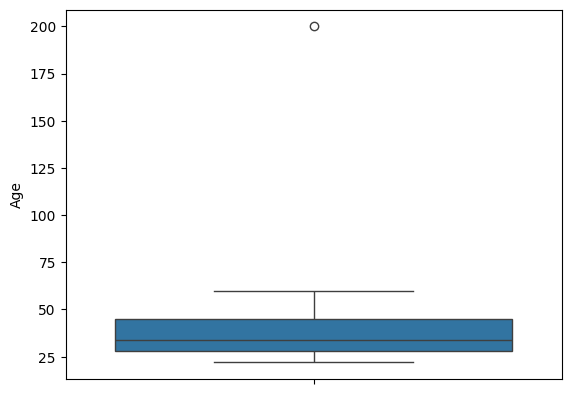

In [51]:
sns.boxplot(df['Age'])


<Axes: ylabel='Salary'>

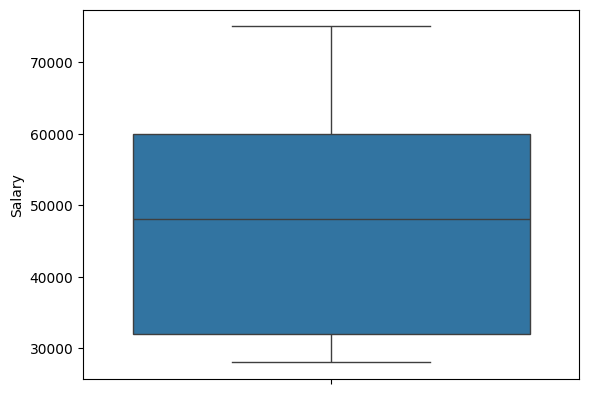

In [53]:
sns.boxplot(df['Salary'])

<Axes: ylabel='City'>

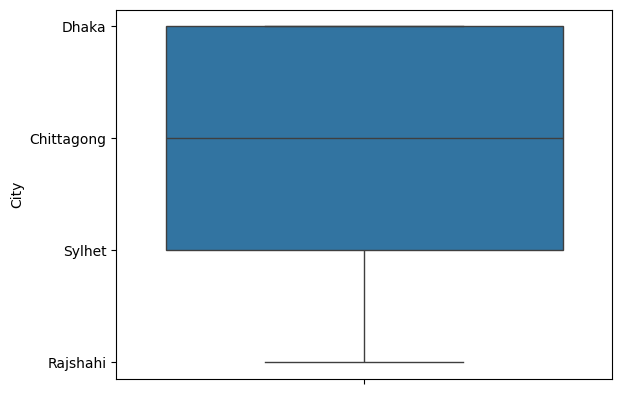

In [54]:
sns.boxplot(df['City'])

## **Missing → Outlier → Encoding → Scaling → Split**

## **tricks:**

# 👉 **Imputer = fill the blank**

# 👉 **Encoding = text → number**

# 👉**Scaling = number normaliz**



# **Imputer handles missing values,**

# **Encoding converts categorical data into numerical form,**

# **and Scaling normalizes numerical features for machine learning models.**